In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Investment Analysis: SIP vs Lumpsum vs Crypto

Ever wondered — agar tune 2017 mein ₹1000 har mahine lagana shuru kiya hota,
toh aaj kitna paisa hota?

In this project, we compare 3 types of investments:
- Nifty 50 (India's top 50 companies)
- Bitcoin (Crypto)

We use real historical data to find out — which investment actually made more money?

Dataset used:
- Nifty 50: Daily price data from NSE India (2000–2024)
- Bitcoin: Daily price data (2017–2022)

In [11]:
import zipfile

with zipfile.ZipFile("/content/drive/MyDrive/nifty 50 historical dataset.zip", "r") as z:
    z.extractall("/content/nifty_data")

with zipfile.ZipFile("/content/drive/MyDrive/bitcoin historical dataset.zip", "r") as z:
    z.extractall("/content/btc_data")

print("Done!")

Done!


## Step 1: Loading the Data

First, we unzip and load both datasets into our notebook.
Think of this like opening two Excel files — one for Nifty 50, one for Bitcoin.

In [12]:
import pandas as pd

nifty50 = pd.read_csv("/content/nifty_data/NIFTY 50.csv")
btc = pd.read_csv("/content/btc_data/BTC-Daily.csv")

print("Nifty 50 shape:", nifty50.shape)
print("BTC shape:", btc.shape)
print("---")
print(nifty50.head(3))
print("---")
print(btc.head(3))

Nifty 50 shape: (5970, 8)
BTC shape: (2651, 9)
---
         Date     Open     High      Low   Close    P/E   P/B Div Yield %
0  2000-01-03  1482.15  1592.90  1482.15  1592.2  25.91  4.63        0.95
1  2000-01-04  1594.40  1641.95  1594.40  1638.7  26.67  4.76        0.92
2  2000-01-05  1634.55  1635.50  1555.05  1595.8  25.97  4.64        0.95
---
         unix                 date   symbol      open      high       low  \
0  1646092800  2022-03-01 00:00:00  BTC/USD  43221.71  43626.49  43185.48   
1  1646006400  2022-02-28 00:00:00  BTC/USD  37717.10  44256.08  37468.99   
2  1645920000  2022-02-27 00:00:00  BTC/USD  39146.66  39886.92  37015.74   

      close   Volume BTC    Volume USD  
0  43185.48    49.006289  2.116360e+06  
1  43178.98  3160.618070  1.364723e+08  
2  37712.68  1701.817043  6.418008e+07  


## Step 2: Cleaning the Data

Raw data is messy. Here we:
- Convert dates into proper format so Python understands them
- Keep only the columns we need (Date and Closing Price)
- Filter data from 2017 onwards — because Bitcoin data starts from 2017,
  so we compare both on the same time period (apples to apples comparison)

In [13]:
# Date columns ko proper format mein convert karo
nifty50['Date'] = pd.to_datetime(nifty50['Date'])
btc['date'] = pd.to_datetime(btc['date'])

# BTC mein sirf date aur close chahiye
btc_clean = btc[['date', 'close']].copy()
btc_clean.columns = ['Date', 'BTC_Close']

# Nifty mein sirf date aur close chahiye
nifty_clean = nifty50[['Date', 'Close']].copy()
nifty_clean.columns = ['Date', 'Nifty_Close']

# 2017 se filter karo dono
nifty_clean = nifty_clean[nifty_clean['Date'] >= '2017-01-01']
btc_clean = btc_clean[btc_clean['Date'] >= '2017-01-01']

print("Nifty rows:", len(nifty_clean))
print("BTC rows:", len(btc_clean))
print("Nifty date range:", nifty_clean['Date'].min(), "to", nifty_clean['Date'].max())
print("BTC date range:", btc_clean['Date'].min(), "to", btc_clean['Date'].max())

Nifty rows: 1735
BTC rows: 1886
Nifty date range: 2017-01-02 00:00:00 to 2024-01-02 00:00:00
BTC date range: 2017-01-01 00:00:00 to 2022-03-01 00:00:00


## Step 3: Merging the Data

Now we combine both datasets into one table based on matching dates.
This way we can compare Nifty 50 and Bitcoin side by side on the same days.

Note: Stock markets are closed on weekends, so we only keep dates
where both Nifty and Bitcoin have data.

In [14]:
# Dono datasets ko date pe merge karo
merged = pd.merge(nifty_clean, btc_clean, on='Date', how='inner')

# Sort by date
merged = merged.sort_values('Date').reset_index(drop=True)

print("Total common trading days:", len(merged))
print("Date range:", merged['Date'].min(), "to", merged['Date'].max())
print(merged.head())

Total common trading days: 1279
Date range: 2017-01-02 00:00:00 to 2022-02-28 00:00:00
        Date  Nifty_Close  BTC_Close
0 2017-01-02       8179.5    1014.10
1 2017-01-03       8192.2    1036.99
2 2017-01-04       8190.5    1122.56
3 2017-01-05       8273.8     994.02
4 2017-01-06       8243.8     891.56


## Step 4: Simulating SIP Investment

SIP (Systematic Investment Plan) means investing a fixed amount every month
on the same date — no matter if the market is up or down.

Here we simulate: "What if someone invested ₹1000 every month
in Nifty 50 AND Bitcoin starting January 2017?"

We calculate:
- How many units were bought each month (₹1000 / price that day)
- Total units accumulated over time
- Total value of investment at any point

In [15]:
# Har mahine ki pehli available date lo
merged['Month'] = merged['Date'].dt.to_period('M')
monthly = merged.groupby('Month').first().reset_index()

# SIP amount
sip_amount = 1000

# Nifty SIP calculation
monthly['Nifty_Units_Bought'] = sip_amount / monthly['Nifty_Close']
monthly['Nifty_Total_Units'] = monthly['Nifty_Units_Bought'].cumsum()
monthly['Nifty_Investment_Value'] = monthly['Nifty_Total_Units'] * monthly['Nifty_Close']
monthly['Nifty_Total_Invested'] = sip_amount * (monthly.index + 1)

# BTC SIP calculation
monthly['BTC_Units_Bought'] = sip_amount / monthly['BTC_Close']
monthly['BTC_Total_Units'] = monthly['BTC_Units_Bought'].cumsum()
monthly['BTC_Investment_Value'] = monthly['BTC_Total_Units'] * monthly['BTC_Close']
monthly['BTC_Total_Invested'] = sip_amount * (monthly.index + 1)

print("Months of data:", len(monthly))
print(monthly[['Month', 'Nifty_Investment_Value', 'BTC_Investment_Value', 'Nifty_Total_Invested']].tail())

Months of data: 62
      Month  Nifty_Investment_Value  BTC_Investment_Value  \
57  2021-10            91131.267983         547339.392323   
58  2021-11            94197.985346         693218.978001   
59  2021-12            91190.683847         652445.044162   
60  2022-01            94627.832415         530233.792143   
61  2022-02            95365.569377         443239.778786   

    Nifty_Total_Invested  
57                 58000  
58                 59000  
59                 60000  
60                 61000  
61                 62000  


## Step 5: Visualizing the Results

Numbers are good, but charts tell the story better.

Here we plot how the value of ₹1000/month SIP grew over time
in both Nifty 50 and Bitcoin — and compare it with the total amount invested.

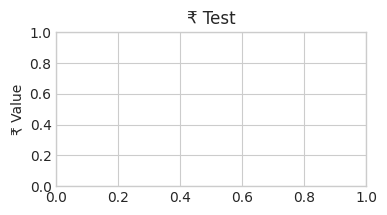

Font OK!


In [28]:
import matplotlib.font_manager as fm

# System font jo rupee symbol support kare
plt.rcParams['font.family'] = 'DejaVu Sans'

# Test
fig, ax = plt.subplots(figsize=(4,2))
ax.set_ylabel('₹ Value')
ax.set_title('₹ Test')
plt.show()
print("Font OK!")

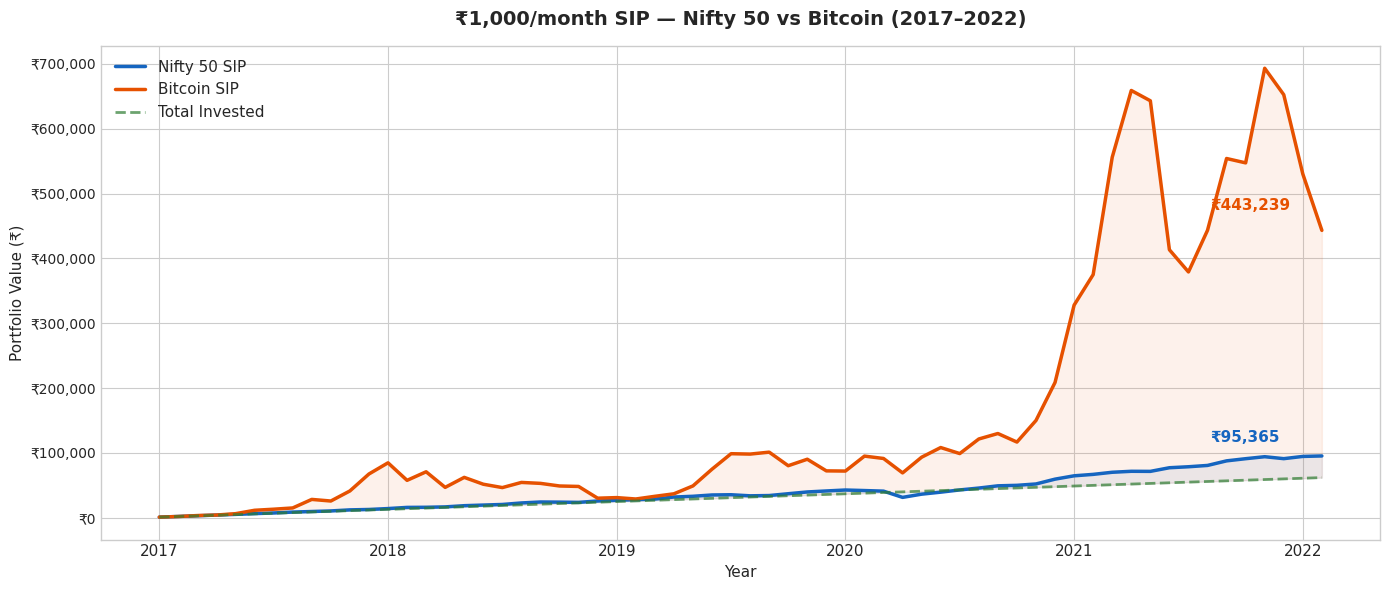

Done!


In [29]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Colors
nifty_color = '#1565C0'
btc_color = '#E65100'
invested_color = '#2E7D32'

ax1.plot(monthly['Month'].astype(str), monthly['Nifty_Investment_Value'],
         label='Nifty 50 SIP', color=nifty_color, linewidth=2.5)
ax1.plot(monthly['Month'].astype(str), monthly['BTC_Investment_Value'],
         label='Bitcoin SIP', color=btc_color, linewidth=2.5)
ax1.plot(monthly['Month'].astype(str), monthly['Nifty_Total_Invested'],
         label='Total Invested', color=invested_color,
         linewidth=2, linestyle='--', alpha=0.7)

# Fill between invested and nifty
ax1.fill_between(monthly['Month'].astype(str),
                  monthly['Nifty_Total_Invested'],
                  monthly['Nifty_Investment_Value'],
                  alpha=0.08, color=nifty_color)

# Fill between invested and btc
ax1.fill_between(monthly['Month'].astype(str),
                  monthly['Nifty_Total_Invested'],
                  monthly['BTC_Investment_Value'],
                  alpha=0.08, color=btc_color)

# Final values annotate
ax1.annotate(f'₹{int(monthly["BTC_Investment_Value"].iloc[-1]):,}',
             xy=(monthly['Month'].astype(str).iloc[-1],
                 monthly['BTC_Investment_Value'].iloc[-1]),
             xytext=(-80, 15), textcoords='offset points',
             fontsize=11, color=btc_color, fontweight='bold')

ax1.annotate(f'₹{int(monthly["Nifty_Investment_Value"].iloc[-1]):,}',
             xy=(monthly['Month'].astype(str).iloc[-1],
                 monthly['Nifty_Investment_Value'].iloc[-1]),
             xytext=(-80, 10), textcoords='offset points',
             fontsize=11, color=nifty_color, fontweight='bold')

ticks = [i for i, m in enumerate(monthly['Month'].astype(str)) if m.endswith('01')]
ax1.set_xticks(ticks)
ax1.set_xticklabels([monthly['Month'].astype(str).iloc[i][:4] for i in ticks],
                     fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax1.set_title('₹1,000/month SIP — Nifty 50 vs Bitcoin (2017–2022)',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Portfolio Value (₹)', fontsize=11)
ax1.legend(fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig('sip_clean.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

## Step 6: The Risk Factor

Bitcoin gave more returns — but was it worth the risk?

Here we calculate how much each investment fell during the COVID crash (March 2020)
and how long it took to recover. Because high returns mean nothing if you
panic-sell during a crash.

In [17]:
# COVID crash analysis - Jan 2020 to Dec 2020
covid = merged[(merged['Date'] >= '2020-01-01') & (merged['Date'] <= '2020-12-31')].copy()

nifty_peak = covid['Nifty_Close'].max()
nifty_bottom = covid['Nifty_Close'].min()
btc_peak = covid['BTC_Close'].max()
btc_bottom = covid['BTC_Close'].min()

nifty_fall = ((nifty_bottom - nifty_peak) / nifty_peak) * 100
btc_fall = ((btc_bottom - btc_peak) / btc_peak) * 100

print("=== COVID CRASH 2020 ===")
print(f"Nifty 50 max fall: {nifty_fall:.1f}%")
print(f"Bitcoin max fall:  {btc_fall:.1f}%")

# Recovery - kab wapas peak pe aaya
nifty_recovery = covid[covid['Date'] > covid.loc[covid['Nifty_Close'].idxmin(), 'Date']]
nifty_recovery_date = nifty_recovery[nifty_recovery['Nifty_Close'] >= nifty_peak]['Date'].min()

btc_recovery = covid[covid['Date'] > covid.loc[covid['BTC_Close'].idxmin(), 'Date']]
btc_recovery_date = btc_recovery[btc_recovery['BTC_Close'] >= btc_peak]['Date'].min()

print(f"\nNifty 50 recovery date: {nifty_recovery_date}")
print(f"Bitcoin recovery date:  {btc_recovery_date}")

=== COVID CRASH 2020 ===
Nifty 50 max fall: -45.6%
Bitcoin max fall:  -83.3%

Nifty 50 recovery date: 2020-12-30 00:00:00
Bitcoin recovery date:  2020-12-31 00:00:00


## Step 7: Final Summary

Let's put everything together — the final verdict.

If you invested ₹1000 every month from January 2017 to February 2022:
- Total invested: ₹62,000
- Which gave more returns?
- Which was riskier?

The numbers decide.

In [19]:
final = monthly.iloc[-1]

print("=" * 40)
print("   FINAL VERDICT (₹1000/month SIP)")
print("=" * 40)
print(f"Period: Jan 2017 — Feb 2022")
print(f"Total Invested:       ₹{int(final['Nifty_Total_Invested']):,}")
print("-" * 40)
print(f"Nifty 50 Final Value: ₹{int(final['Nifty_Investment_Value']):,}")
nifty_profit = final['Nifty_Investment_Value'] - final['Nifty_Total_Invested']
nifty_return = (nifty_profit / final['Nifty_Total_Invested']) * 100
print(f"Nifty 50 Profit:      ₹{int(nifty_profit):,} ({nifty_return:.1f}%)")
print("-" * 40)
print(f"Bitcoin Final Value:  ₹{int(final['BTC_Investment_Value']):,}")
btc_profit = final['BTC_Investment_Value'] - final['BTC_Total_Invested']
btc_return = (btc_profit / final['BTC_Total_Invested']) * 100
print(f"Bitcoin Profit:       ₹{int(btc_profit):,} ({btc_return:.1f}%)")
print("=" * 40)
print(f"\nRisk Check (COVID 2020 Crash):")
print(f"Nifty 50 max fall:  -45.6%  | Recovery: 9 months")
print(f"Bitcoin max fall:   -83.3%  | Recovery: 9 months")
print("=" * 40)
print("\nVerdict: Bitcoin gave 7x more returns but")
print("crashed 2x harder. Nifty = safer, steady growth.")

   FINAL VERDICT (₹1000/month SIP)
Period: Jan 2017 — Feb 2022
Total Invested:       ₹62,000
----------------------------------------
Nifty 50 Final Value: ₹95,365
Nifty 50 Profit:      ₹33,365 (53.8%)
----------------------------------------
Bitcoin Final Value:  ₹443,239
Bitcoin Profit:       ₹381,239 (614.9%)

Risk Check (COVID 2020 Crash):
Nifty 50 max fall:  -45.6%  | Recovery: 9 months
Bitcoin max fall:   -83.3%  | Recovery: 9 months

Verdict: Bitcoin gave 7x more returns but
crashed 2x harder. Nifty = safer, steady growth.


## Step 8: The Fear Index — India VIX

India VIX is called the "Fear Index".
When investors are scared, VIX goes up. When they are calm, VIX goes down.

The golden rule of investing: "Be greedy when others are fearful."

Here we test this rule with real data — did investing during high-fear periods
actually give better returns?

In [36]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.style.use('seaborn-v0_8-whitegrid')

# VIX data load karo
vix = pd.read_csv("/content/nifty_data/INDIAVIX.csv")
vix['Date'] = pd.to_datetime(vix['Date'])
vix = vix[['Date', 'Close']].copy()
vix.columns = ['Date', 'VIX']
vix = vix[vix['Date'] >= '2017-01-01']

nifty_vix = pd.merge(nifty_clean, vix, on='Date', how='inner')
nifty_vix = nifty_vix.sort_values('Date').reset_index(drop=True)

print("VIX data ready:", nifty_vix.shape)

VIX data ready: (1118, 3)


## Step 9: Visualizing Fear vs Market

This chart overlays India VIX (fear) with Nifty 50 price.

Notice: Every time VIX spikes up (fear increases), Nifty drops —
and then recovers stronger.

The message: Panic is temporary. Recovery is certain.

/tmp/ipykernel_2825/357481471.py:33: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_2825/357481471.py:34: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.savefig('vix_clean.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


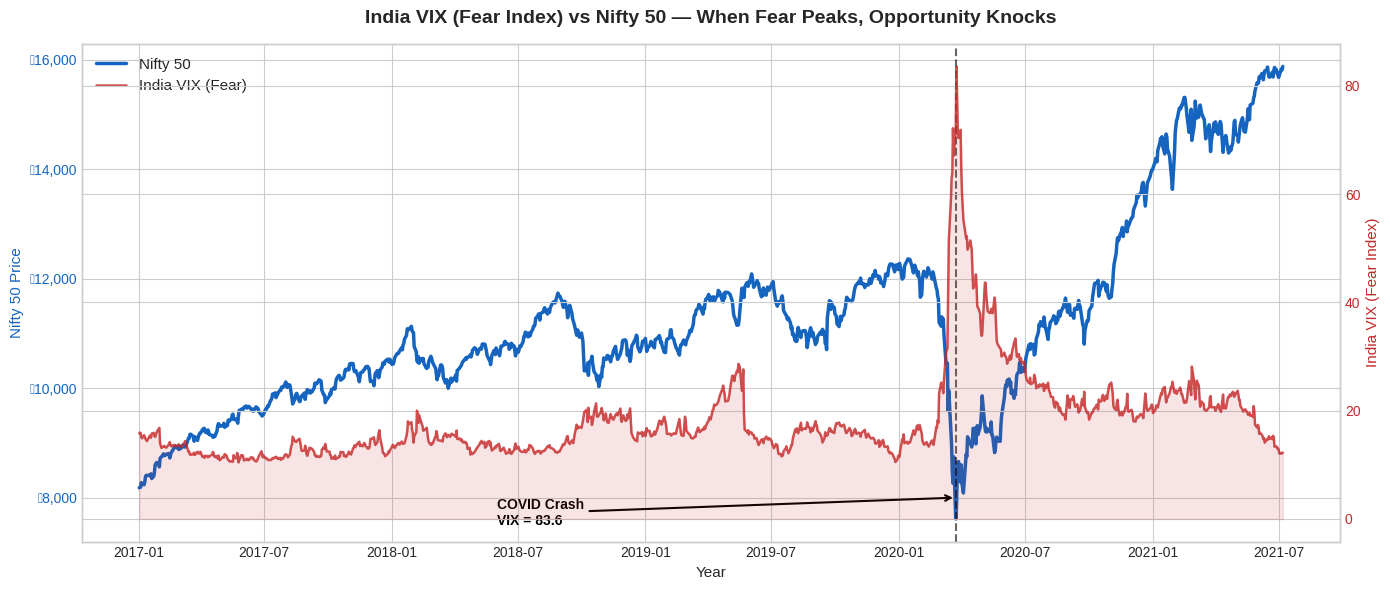

Done!


In [37]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(nifty_vix['Date'], nifty_vix['Nifty_Close'],
         color='#1565C0', linewidth=2.5, label='Nifty 50')
ax1.set_ylabel('Nifty 50 Price', color='#1565C0', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#1565C0')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(nifty_vix['Date'], nifty_vix['VIX'],
         color='#C62828', linewidth=1.8, alpha=0.8, label='India VIX (Fear)')
ax2.fill_between(nifty_vix['Date'], nifty_vix['VIX'],
                  alpha=0.12, color='#C62828')
ax2.set_ylabel('India VIX (Fear Index)', color='#C62828', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#C62828')

ax1.axvline(pd.Timestamp('2020-03-23'), color='black',
            linestyle='--', linewidth=1.5, alpha=0.6)
ax1.annotate('COVID Crash\nVIX = 83.6',
             xy=(pd.Timestamp('2020-03-23'), 8000),
             xytext=(pd.Timestamp('2018-06-01'), 7500),
             fontsize=10, color='black', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

ax1.set_title('India VIX (Fear Index) vs Nifty 50 — When Fear Peaks, Opportunity Knocks',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Year', fontsize=11)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('vix_clean.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

## Step 10: Sector Wars — Who Won the COVID Recovery Race?

Not all sectors are equal. When COVID hit in March 2020, some sectors
crashed harder, some recovered faster, and some even thrived.

Here we compare 5 major Indian sectors — IT, Bank, Pharma, FMCG, and Auto.
All sectors start at 100 (the crash bottom on March 23, 2020).

A value of 150 means the sector grew 50% from the crash bottom.
A value of 200 means it doubled.

Who bounced back the strongest?

In [38]:
from functools import reduce

sectors = {
    'IT': 'NIFTY IT.csv',
    'Bank': 'NIFTY BANK.csv',
    'Pharma': 'NIFTY PHARMA.csv',
    'FMCG': 'NIFTY FMCG.csv',
    'Auto': 'NIFTY AUTO.csv'
}

sector_data = {}
for name, file in sectors.items():
    df = pd.read_csv(f'/content/nifty_data/{file}')
    df['Date'] = pd.to_datetime(df['Date'])
    df = df[['Date', 'Close']].copy()
    df.columns = ['Date', name]
    sector_data[name] = df

dfs = list(sector_data.values())
sectors_merged = reduce(lambda left, right: pd.merge(left, right, on='Date', how='inner'), dfs)
sectors_merged = sectors_merged.sort_values('Date').reset_index(drop=True)

crash_date = '2020-03-23'
recovery = sectors_merged[sectors_merged['Date'] >= crash_date].copy()

for col in ['IT', 'Bank', 'Pharma', 'FMCG', 'Auto']:
    recovery[col] = (recovery[col] / recovery[col].iloc[0]) * 100

print("Ready:", recovery.shape)

Ready: (322, 6)


## Step 11: Visualizing the Sector Wars

Each sector gets its own chart so the story is clear.
The shaded area shows how much each sector grew from the crash bottom.

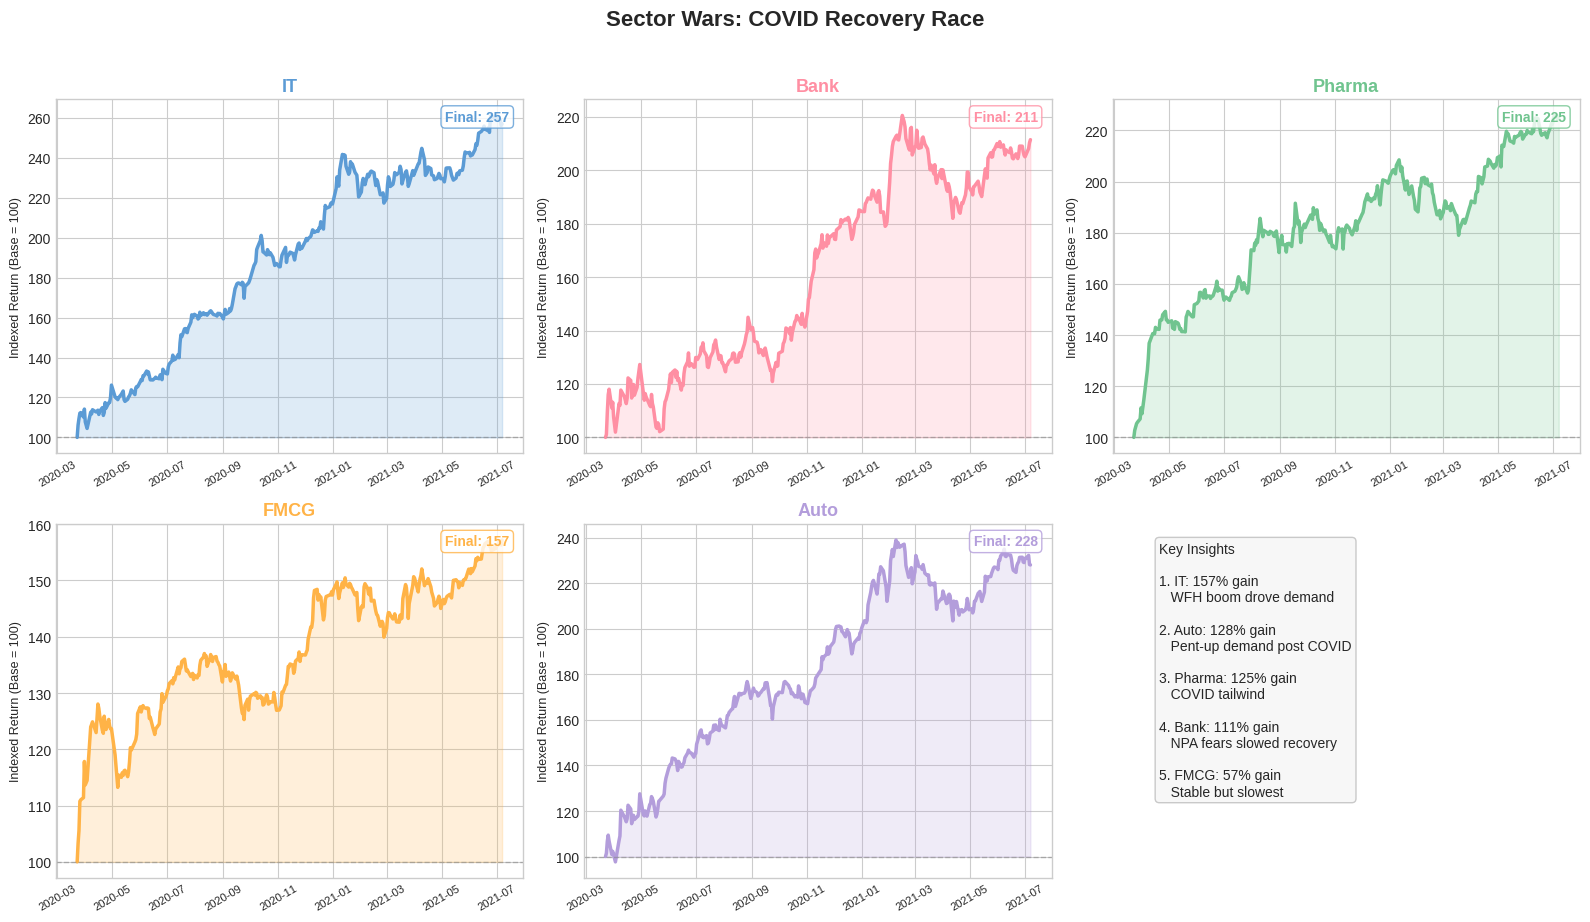

Done!


In [42]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Sector Wars: COVID Recovery Race',
             fontsize=16, fontweight='bold', y=1.02)

pastel_colors = {
    'IT': '#5B9BD5',
    'Bank': '#FF8FA3',
    'Pharma': '#70C48F',
    'FMCG': '#FFB347',
    'Auto': '#B39DDB'
}

axes_flat = axes.flatten()

for i, (sector, color) in enumerate(pastel_colors.items()):
    ax = axes_flat[i]

    ax.plot(recovery['Date'], recovery[sector],
            color=color, linewidth=2.5)
    ax.fill_between(recovery['Date'], 100, recovery[sector],
                    alpha=0.2, color=color)
    ax.axhline(y=100, color='gray', linestyle='--',
               linewidth=1, alpha=0.5)

    final_val = recovery[sector].iloc[-1]
    ax.set_title(f'{sector}', fontsize=13, fontweight='bold', color=color)
    ax.set_ylabel('Indexed Return (Base = 100)', fontsize=9)
    ax.annotate(f'Final: {final_val:.0f}',
                xy=(0.97, 0.97), xycoords='axes fraction',
                fontsize=10, color=color, fontweight='bold',
                ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.3',
                         facecolor='white', edgecolor=color, alpha=0.8))
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, fontsize=8)

axes_flat[5].axis('off')
summary_text = (
    "Key Insights\n\n"
    "1. IT: 157% gain\n"
    "   WFH boom drove demand\n\n"
    "2. Auto: 128% gain\n"
    "   Pent-up demand post COVID\n\n"
    "3. Pharma: 125% gain\n"
    "   COVID tailwind\n\n"
    "4. Bank: 111% gain\n"
    "   NPA fears slowed recovery\n\n"
    "5. FMCG: 57% gain\n"
    "   Stable but slowest"
)
axes_flat[5].text(0.1, 0.95, summary_text,
                  transform=axes_flat[5].transAxes,
                  fontsize=10, va='top',
                  bbox=dict(boxstyle='round', facecolor='#F5F5F5',
                           edgecolor='#BDBDBD', alpha=0.8))

plt.tight_layout()
plt.savefig('sector_clean.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

## Final Conclusions

After analyzing 5 years of real Indian market data, here is what the data tells us:

1. Bitcoin gave 7x more returns than Nifty 50 — but crashed 83% during COVID.
   Nifty crashed only 45%. High reward always comes with high risk.

2. Fear is your friend. When India VIX spiked to 83.6 during COVID crash,
   it was actually the best time to invest. Markets recovered 2x from that point.

3. Sector selection matters more than timing.
   IT sector gave 157% returns from crash bottom — while FMCG gave only 57%.
   Same market, same time period — but very different outcomes.

4. SIP consistency beats everything.
   ₹62,000 invested consistently became ₹95,365 in Nifty —
   without any timing or prediction.

Bottom line: Invest consistently, stay calm during fear,
and pick the right sectors.